In [ ]:
import numpy as np

def load_images(filename):
    with open(filename, 'rb') as f:
        f.read(16)
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(-1, 28, 28)

def load_labels(filename):
    with open(filename, 'rb') as f:
        f.read(8)
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data

X_train = load_images("C:\\Users\\alias\\Downloads\\archive\\train-images.idx3-ubyte")
y_train = load_labels("C:\\Users\\alias\\Downloads\\archive\\train-labels.idx1-ubyte")

X_test = load_images("C:\\Users\\alias\\Downloads\\archive\\t10k-images.idx3-ubyte")
y_test = load_labels("C:\\Users\\alias\\Downloads\\archive\\t10k-labels.idx1-ubyte")

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [1]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from tensorflow.keras import layers, models

input_dim = 784
latent_dim = 16

input_img = layers.Input(shape=(input_dim,))
x = layers.Dense(256, activation='relu')(input_img)
x = layers.Dense(64, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='relu')(x)

x = layers.Dense(64, activation='relu')(latent)
x = layers.Dense(256, activation='relu')(x)
output = layers.Dense(input_dim, activation='sigmoid')(x)

autoencoder = models.Model(input_img, output)
encoder = models.Model(input_img, latent)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [10]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2389 - val_loss: 0.1673
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1518 - val_loss: 0.1403
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1333 - val_loss: 0.1266
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1236 - val_loss: 0.1200
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1184 - val_loss: 0.1161
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1148 - val_loss: 0.1130
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1121 - val_loss: 0.1111
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1101 - val_loss: 0.1091
Epoch 9/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1084 - val_loss: 0.1082
Epoch 10/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1071 - val_loss: 0.1067
Epoch 11/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1060 - val_loss: 0.1057
Epoch 12/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Loss

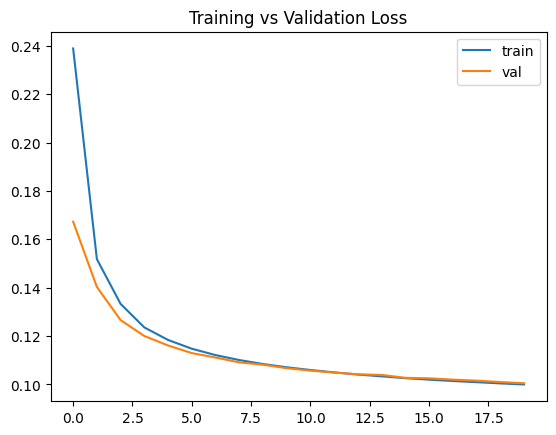

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

latent space

In [12]:
z = encoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step


K-Means

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(z)

t-SNE

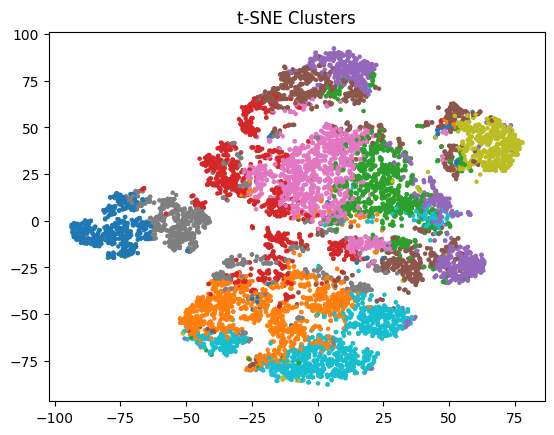

In [14]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(z)

plt.scatter(z_2d[:, 0], z_2d[:, 1], c=clusters, cmap='tab10', s=5)
plt.title("t-SNE Clusters")
plt.show()

Confusion Matrix

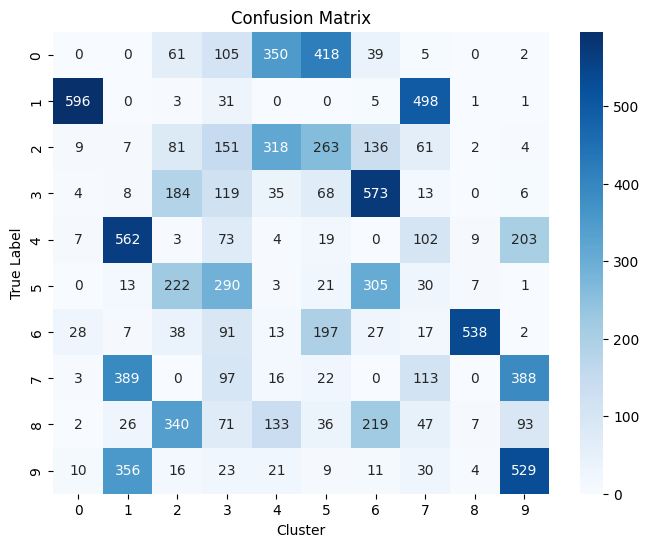

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, clusters)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Cluster")
plt.ylabel("True Label")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


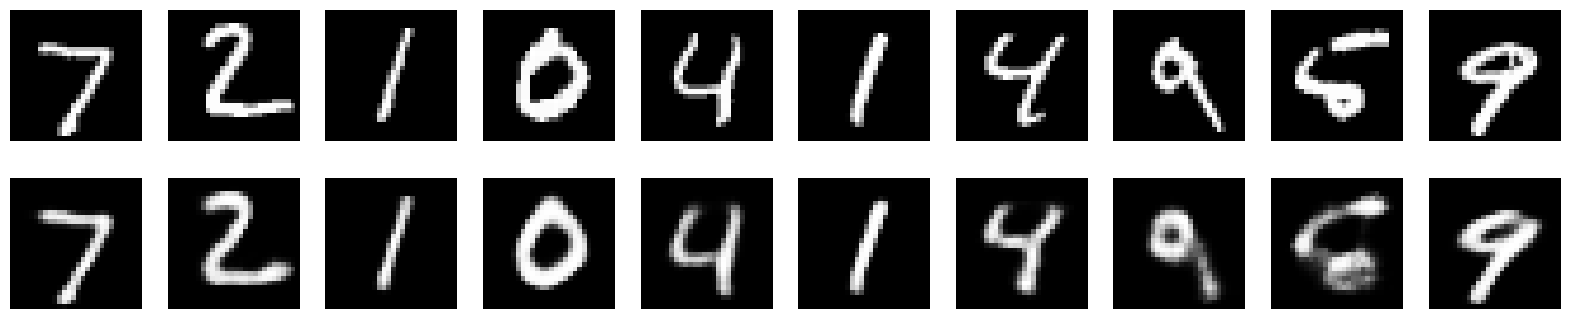

In [ ]:
decoded = autoencoder.predict(X_test)

n = 10
plt.figure(figsize=(20,4))

for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()